---
title: "N1: Sample Data Exploration"
---

## Overview

This notebook demonstrates the template workflow: generating synthetic data,
producing labeled figures and tables that are embedded in the manuscript via
Quarto's `{{< embed >}}` shortcode.

In [1]:
import sys
sys.path.insert(0, "..")
from config import set_seeds, DATA_DIR

set_seeds()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

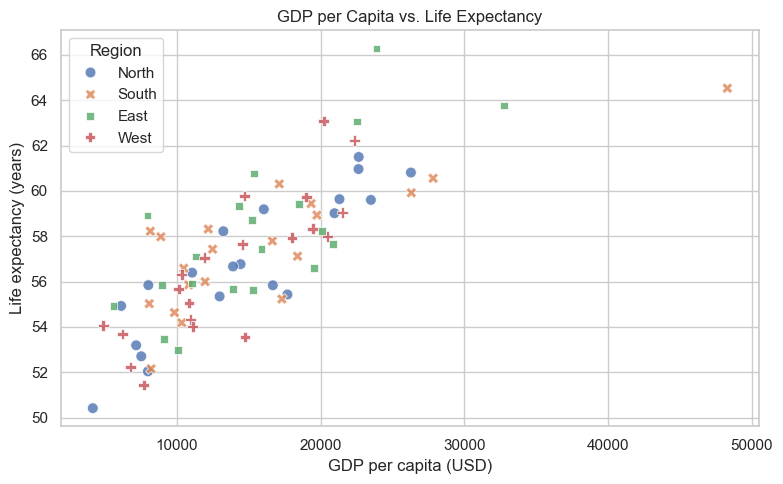

In [3]:
#| label: fig-sample
#| fig-cap: "Synthetic regional indicators: GDP per capita vs. life expectancy across 80 simulated regions, colored by geographic cluster."

# Generate synthetic cross-sectional data
rng = np.random.default_rng(42)
n = 80
clusters = np.repeat(["North", "South", "East", "West"], n // 4)

gdp = rng.lognormal(mean=9.5, sigma=0.6, size=n)
life_exp = 50 + 15 * (1 - np.exp(-gdp / 20000)) + rng.normal(0, 2, n)

df = pd.DataFrame({
    "GDP per capita (USD)": gdp,
    "Life expectancy (years)": life_exp,
    "Region": clusters,
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="GDP per capita (USD)",
    y="Life expectancy (years)",
    hue="Region",
    style="Region",
    s=60,
    alpha=0.8,
    ax=ax,
)
ax.set_title("GDP per Capita vs. Life Expectancy")
ax.legend(title="Region", frameon=True)
plt.tight_layout()
plt.show()

In [4]:
#| label: tbl-summary
#| tbl-cap: "Summary statistics by region."

summary = (
    df.groupby("Region")[["GDP per capita (USD)", "Life expectancy (years)"]]
    .agg(["mean", "std", "count"])
    .round(1)
)
summary.columns = [f"{col} ({stat})" for col, stat in summary.columns]
from IPython.display import Markdown
Markdown(summary.to_markdown())

| Region   |   GDP per capita (USD) (mean) |   GDP per capita (USD) (std) |   GDP per capita (USD) (count) |   Life expectancy (years) (mean) |   Life expectancy (years) (std) |   Life expectancy (years) (count) |
|:---------|------------------------------:|-----------------------------:|-------------------------------:|---------------------------------:|--------------------------------:|----------------------------------:|
| East     |                       15607.9 |                       6499.5 |                             20 |                             58.1 |                             3.4 |                                20 |
| North    |                       14709   |                       6638.8 |                             20 |                             56.7 |                             3.1 |                                20 |
| South    |                       16113.3 |                       9541.1 |                             20 |                             57.5 |                             2.8 |                                20 |
| West     |                       13787   |                       5498.2 |                             20 |                             56.7 |                             3.2 |                                20 |